In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath("..")) 

from datetime import datetime, timedelta
from typing import Optional

## Modulo para preprocesadores de los datos
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import StandardScaler

## Modulo para evaluacion, split y construccion pipeline
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay,roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.impute import SimpleImputer

## Modulo de algoritmos para entrenamiento
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from src.paths import RAW_DIR
from src.validation import validate_missing_duplicates, validate_date_columns
from src.explorer import summary_stats
from src.features import summarize_customer_activity

# Apply the default theme
sns.set_theme()


In [2]:
# =========================
# CONFIGURACIÓN INICIAL
# =========================
np.random.seed(42)
random.seed(42)

# Rango de fechas
start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 8, 31)

# Ciudades colombianas
cities = ["Bogotá", "Medellín", "Cali", "Barranquilla", "Cartagena",
          "Bucaramanga", "Pereira", "Manizales", "Santa Marta", "Cúcuta"]

# Posibles valores para cada feature
genders = ["M", "F"]
channels = ["presencial", "online", "social_media"]
categories = ["technology", "pharmacy", "tools_construction", "pets"]
devices = ["mobile", "desktop"]
payment_methods = ["credit_card", "debit_card", "account_money", "money_transfer"]

# Número de clientes unicos
n_customers =10000

In [3]:
# =========================
# GENERACIÓN DE CUSTOMERS
# =========================

# Crear IDs únicos aleatorios para clientes
customer_ids = [f"CUST-{str(i).zfill(5)}" for i in range(1, n_customers + 1)]

signup_dates = [
    start_date + timedelta(days=random.randint(0, (end_date - start_date).days))
    for _ in range(n_customers)
]

ages = np.clip(np.random.normal(loc=35, scale=10, size=n_customers), 18, 72).astype(int)

customers = pd.DataFrame({
    "customer_id": customer_ids,
    "signup_date": signup_dates,
    "gender": np.random.choice(genders, size=n_customers),
    "city": np.random.choice(cities, size=n_customers),
    "channel": np.random.choice(channels, size=n_customers),
    "is_premium": np.random.choice([0, 1], size=n_customers, p=[0.7, 0.3]),
    "age": ages
})

customers["signup_date"] = pd.to_datetime(customers["signup_date"])


In [4]:
# ===========================
# GENERACIÓN DE TRANSACTIONS
# ===========================

transactions = []
order_id_counter = 1

for cust_id in customer_ids:
    n_orders = np.random.poisson(lam=5)
    signup_date = customers.loc[customers["customer_id"] == cust_id, "signup_date"].iloc[0]
    
    for _ in range(n_orders):
        order_date = signup_date + timedelta(days=random.randint(0, (end_date - signup_date).days))
        order_amount = round(np.random.exponential(scale=200), 2) + 10
        category = random.choice(categories)
        device = random.choice(devices)
        payment_method = random.choice(payment_methods)

        order_id = f"ORD-{str(order_id_counter).zfill(7)}"
        
        transactions.append([
            cust_id, order_id, order_date, order_amount, category, device, payment_method
        ])
        order_id_counter += 1

transactions_df = pd.DataFrame(transactions, columns=[
    "customer_id", "order_id", "order_date", "order_amount", "category", "device", "payment_method"
])


In [5]:
# =========================
# EXPORTAR A CSV
# =========================
# Convertir lista a DataFrame
transactions = pd.DataFrame(transactions, columns=[
    "customer_id", "order_id", "order_date", "order_amount",
    "category", "device", "payment_method"
])

# =========================
# EXPORTAR A CSV
# =========================

# Crear carpeta si no existe
customers.to_csv(RAW_DIR / "customers.csv", index=False)
transactions.to_csv(RAW_DIR / "transactions.csv", index=False)

print("✅ Archivos generados: customers.csv y transactions.csv")


✅ Archivos generados: customers.csv y transactions.csv


## 2) EDA “flash”

### Revisa faltantes, duplicados y coherencia de fechas.

In [6]:
# Validación de faltantes y duplicados en customers y transactions
res1 = validate_missing_duplicates(customers, transactions)

# Validación de fechas en ambos DF
res2 = validate_date_columns({
    "customers": (customers, ["signup_date"]),
    "transactions": (transactions_df, ["order_date"])
})

print("=== Validacion Faltantes y Duplicados ===")
print(res1, "\n")
print("=== Validacion Formato Fechas  ===")
print(res2, "\n")


=== Validacion Faltantes y Duplicados ===
{'df_1': {'missing_values': {}, 'duplicate_rows': 0}, 'df_2': {'missing_values': {}, 'duplicate_rows': 0}} 

=== Validacion Formato Fechas  ===
{'customers': {'signup_date': {'invalid_dates': 0, 'min_date': '2023-01-01 00:00:00', 'max_date': '2024-08-31 00:00:00'}}, 'transactions': {'order_date': {'invalid_dates': 0, 'min_date': '2023-01-01 00:00:00', 'max_date': '2024-08-31 00:00:00'}}} 



### Calcula: # clientes, # transacciones, ticket promedio, % premium.

In [7]:
summary_transanctions = summary_stats(transactions)

print("=== Numéricas ===")
print(summary_transanctions["numeric"], "\n")

print("=== Categóricas ===")
print(summary_transanctions["categorical"])


=== Numéricas ===
                count      mean   min      max
order_amount  49800.0  211.1331  10.0  1889.22 

=== Categóricas ===
                count unique_categories top_category top_count top_percentage
customer_id     49800              9911   CUST-01390        15           0.03
order_id        49800             49800  ORD-0000001         1            0.0
category        49800                 4     pharmacy     12490          25.08
device          49800                 2       mobile     24977          50.15
payment_method  49800                 4  credit_card     12581          25.26


In [8]:
summary_customers = summary_stats(customers)

print("=== Numéricas ===")
print(summary_customers["numeric"], "\n")

print("=== Categóricas ===")
print(summary_customers["categorical"])

=== Numéricas ===
              count     mean   min   max
is_premium  10000.0   0.2967   0.0   1.0
age         10000.0  34.6840  18.0  72.0 

=== Categóricas ===
             count unique_categories top_category top_count top_percentage
customer_id  10000             10000   CUST-00001         1           0.01
gender       10000                 2            F      5082          50.82
city         10000                10    Cartagena      1078          10.78
channel      10000                 3       online      3391          33.91


### Grafica un histograma de order_amount y comenta 2 hallazgos rápidos (p. ej., asimetría, outliers).

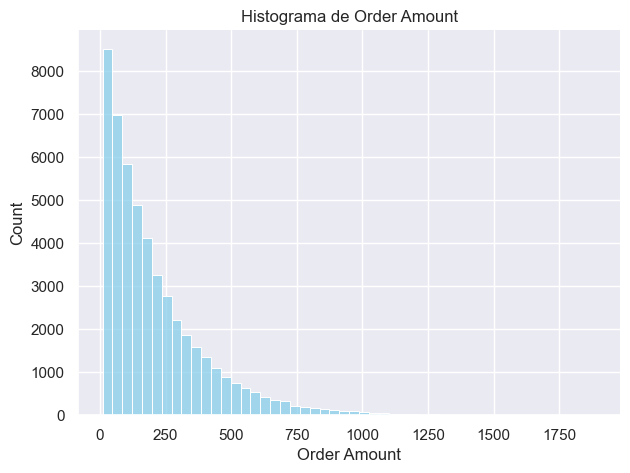

In [9]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)

sns.histplot(
    data=transactions,
    x="order_amount",
    color="skyblue",
    bins=50,
    ax=ax
)

ax.set_xlabel("Order Amount")
ax.set_ylabel("Count")
ax.set_title("Histograma de Order Amount")
plt.show()


Con base en la grafica se puede decir que la distribución del valor de las ordenes tiene una cola pesada hacia la derecha evidenciando que valores superiores a los 750USD se podrian interpretar como valores poco comunes sin ser directamente outliers. De esta misma manera, se puede decir que hay una alta concentración de la distribución a los valores entre los 5 y los 250 USD.

## 3) Modelo baseline

# Construye features simples (usando datos ≤ cutoff):
## - Recency (días desde última compra al cutoff)
## - Frequency_180d (compras en últimos 180 días)
## - Monetary_180d (gasto total en últimos 180 días)

### Para esto se necesita hacer un join entre las tablas customers y transactions:

In [10]:
data = pd.merge(transactions
              ,customers
              ,on="customer_id"
              ,how="left"
              )
data.head(11)

,customer_id,order_id,order_date,order_amount,category,device,payment_method,signup_date,gender,city,channel,is_premium,age
0,CUST-00001,ORD-0000001,2024-05-12,436.13,tools_construction,mobile,credit_card,2023-04-25,F,Santa Marta,social_media,0,39
1,CUST-00001,ORD-0000002,2024-02-29,221.01,pets,mobile,debit_card,2023-04-25,F,Santa Marta,social_media,0,39
2,CUST-00001,ORD-0000003,2023-07-23,245.87,technology,desktop,debit_card,2023-04-25,F,Santa Marta,social_media,0,39
3,CUST-00001,ORD-0000004,2024-01-13,301.57,tools_construction,mobile,money_transfer,2023-04-25,F,Santa Marta,social_media,0,39
4,CUST-00002,ORD-0000005,2024-06-16,86.59,pets,mobile,account_money,2023-01-26,F,Barranquilla,presencial,0,33
5,CUST-00002,ORD-0000006,2023-05-21,34.23,tools_construction,mobile,credit_card,2023-01-26,F,Barranquilla,presencial,0,33
6,CUST-00002,ORD-0000007,2023-11-19,218.37,tools_construction,desktop,account_money,2023-01-26,F,Barranquilla,presencial,0,33
7,CUST-00002,ORD-0000008,2023-10-24,137.61,pharmacy,mobile,money_transfer,2023-01-26,F,Barranquilla,presencial,0,33
8,CUST-00002,ORD-0000009,2023-09-05,59.14,tools_construction,mobile,money_transfer,2023-01-26,F,Barranquilla,presencial,0,33
9,CUST-00003,ORD-0000010,2024-08-20,540.20,pets,mobile,account_money,2023-10-09,M,Santa Marta,social_media,0,41


In [11]:
rfm = summarize_customer_activity(data, cutoff='2024-07-01', window_days=180, fillna=True)
rfm.head()

,customer_id,last_order_date,frequency_180d,monetary_180d,recency_days
0,CUST-00001,2024-05-12,3.0,958.71,50.0
1,CUST-00002,2024-06-16,1.0,86.59,15.0
2,CUST-00003,2023-10-12,0.0,0.00,263.0
3,CUST-00004,2024-03-07,1.0,323.31,116.0
4,CUST-00005,2024-04-22,1.0,295.78,70.0


In [12]:
df = pd.merge(
    rfm
    ,data
    ,left_on=["customer_id", "last_order_date"]
    ,right_on=["customer_id", "order_date"]
    ,how="left"
)
df.head()

,customer_id,last_order_date,frequency_180d,monetary_180d,recency_days,order_id,order_date,order_amount,category,device,payment_method,signup_date,gender,city,channel,is_premium,age
0,CUST-00001,2024-05-12,3.0,958.71,50.0,ORD-0000001,2024-05-12,436.13,tools_construction,mobile,credit_card,2023-04-25,F,Santa Marta,social_media,0.0,39.0
1,CUST-00002,2024-06-16,1.0,86.59,15.0,ORD-0000005,2024-06-16,86.59,pets,mobile,account_money,2023-01-26,F,Barranquilla,presencial,0.0,33.0
2,CUST-00003,2023-10-12,0.0,0.00,263.0,ORD-0000011,2023-10-12,42.65,pets,desktop,account_money,2023-10-09,M,Santa Marta,social_media,0.0,41.0
3,CUST-00004,2024-03-07,1.0,323.31,116.0,ORD-0000012,2024-03-07,323.31,technology,mobile,account_money,2023-09-08,M,Cúcuta,social_media,0.0,50.0
4,CUST-00005,2024-04-22,1.0,295.78,70.0,ORD-0000016,2024-04-22,295.78,technology,mobile,account_money,2023-08-17,M,Bogotá,social_media,1.0,32.0


### A continuación se crea la variable objetivo "will_return_30d" que tomara los valores de 1 si el cliente compra al menos una vez en los 30 días posteriores al cutoff y 0 si no realiza ningu compra. 

### No obstante, esta definición de la variable objetivo puede llegar a generar un problema de data leakage y ademas que se tendra un dataset de entrenamiento solo con valores 0 ya que no satisface la condición de haber tenido una compra en los dias posteriores y el dataset de validacion es posible que solo tome valores de 1 con lo cual esto podria hacer que se tenga problemas con el modelo. 

### De esta manera, se propone realizar un ajuste sobre la construcción de la variable objetivo donde se asumira que hay una fuga del ciente (churn) si tiene una recencia mayor a 15d y la particion de los dataset sera de forma aleatoria tomando siguiendo el estandar de 70-30, es decir, 70% de los datos para entrenamiento y el 30% para validacion 

In [13]:
df["will_return_30d"] = (df["recency_days"] <= 15).astype(int)
df.head()

,customer_id,last_order_date,frequency_180d,monetary_180d,recency_days,order_id,order_date,order_amount,category,device,payment_method,signup_date,gender,city,channel,is_premium,age,will_return_30d
0,CUST-00001,2024-05-12,3.0,958.71,50.0,ORD-0000001,2024-05-12,436.13,tools_construction,mobile,credit_card,2023-04-25,F,Santa Marta,social_media,0.0,39.0,0
1,CUST-00002,2024-06-16,1.0,86.59,15.0,ORD-0000005,2024-06-16,86.59,pets,mobile,account_money,2023-01-26,F,Barranquilla,presencial,0.0,33.0,1
2,CUST-00003,2023-10-12,0.0,0.00,263.0,ORD-0000011,2023-10-12,42.65,pets,desktop,account_money,2023-10-09,M,Santa Marta,social_media,0.0,41.0,0
3,CUST-00004,2024-03-07,1.0,323.31,116.0,ORD-0000012,2024-03-07,323.31,technology,mobile,account_money,2023-09-08,M,Cúcuta,social_media,0.0,50.0,0
4,CUST-00005,2024-04-22,1.0,295.78,70.0,ORD-0000016,2024-04-22,295.78,technology,mobile,account_money,2023-08-17,M,Bogotá,social_media,1.0,32.0,0


## Excluimos features que no aportan valor al analisis como el customer_id, order_id y las fechas.
 ## De igual manera, exlcuimos la vairable recency_days para evitar por supuesto errores de colinealidad con la variable respuesta toda vez que nuestro label esta construido bajo el supuesto de recencias menores de 15d. 


In [14]:
# Lista de columnas a eliminar
cols_to_drop = ["customer_id", "last_order_date", "order_id","order_date","order_amount","signup_date","recency_days"]

# Opción 1: eliminar columnas en el mismo DataFrame
df = df.drop(columns=cols_to_drop)
df.head()

,frequency_180d,monetary_180d,category,device,payment_method,gender,city,channel,is_premium,age,will_return_30d
0,3.0,958.71,tools_construction,mobile,credit_card,F,Santa Marta,social_media,0.0,39.0,0
1,1.0,86.59,pets,mobile,account_money,F,Barranquilla,presencial,0.0,33.0,1
2,0.0,0.00,pets,desktop,account_money,M,Santa Marta,social_media,0.0,41.0,0
3,1.0,323.31,technology,mobile,account_money,M,Cúcuta,social_media,0.0,50.0,0
4,1.0,295.78,technology,mobile,account_money,M,Bogotá,social_media,1.0,32.0,0


In [15]:
# Separar características y variable objetivo
X = df.drop('will_return_30d', axis=1)
y = df['will_return_30d']

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [16]:
print("Distribución en TRAIN:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(3))  # proporciones

print("\nDistribución en TEST:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True).round(3))   # proporciones


Distribución en TRAIN:
will_return_30d
0    4399
1    2601
Name: count, dtype: int64
will_return_30d
0    0.628
1    0.372
Name: proportion, dtype: float64

Distribución en TEST:
will_return_30d
0    1843
1    1158
Name: count, dtype: int64
will_return_30d
0    0.614
1    0.386
Name: proportion, dtype: float64


In [17]:
# Identificacion de variables numéricas y categóricas
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
numerical_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

In [18]:
# Pipeline para variables categóricas
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline para variables numéricas
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('selector', VarianceThreshold(threshold=0.01))
])

In [19]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

In [20]:
# Definición de los modelos a evaluar
modelos = {
    'Regresión Logística': LogisticRegression(
        max_iter=100000
        ,class_weight='balanced'
        , random_state=42,)
    ,'Random Forest': RandomForestClassifier(
        class_weight='balanced'
        ,random_state=42,
    )
}

In [21]:
# Define hiperparámetros
parametros = {
    'Regresión Logística': {
        'classifier__C': [0.01, 0.1, 1, 10]
        ,'classifier__penalty': ['l2']
        ,'classifier__solver': ['lbfgs', 'liblinear']

    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200]
        ,'classifier__max_depth': [None, 10, 20]
        ,'classifier__min_samples_split': [2, 5]
        ,'classifier__bootstrap': [True, False]
}
}


Evaluando modelo: Regresión Logística
🔹 PR-AUC (Average Precision): 0.7263
🔹 ROC-AUC: 0.7429

Evaluando modelo: Random Forest
🔹 PR-AUC (Average Precision): 0.7612
🔹 ROC-AUC: 0.7757


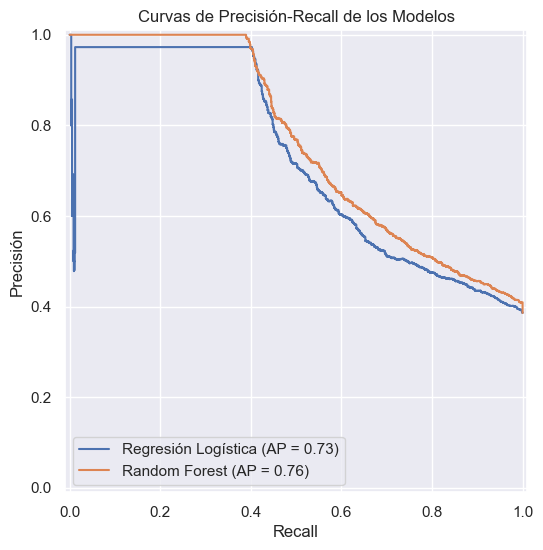


🟢 Mejor modelo (según PR-AUC): RandomForestClassifier(bootstrap=False, class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_estimators=200, random_state=42)
🔢 Mejor PR-AUC: 0.7612


In [22]:

# Inicializar variables
mejor_modelo = None
mejor_ap = 0
mejor_auc = 0

# Crear figura PR
plt.figure(figsize=(12, 6))
plt.title('Curvas de Precisión-Recall de los Modelos')

# Evaluar cada modelo
for nombre, modelo in modelos.items():
    print(f"\nEvaluando modelo: {nombre}")

    # Crear pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', modelo)
    ])

    # Hacer grid search con CV
    grid = GridSearchCV(
        pipeline, 
        param_grid=parametros[nombre], 
        cv=5, 
        scoring='average_precision', 
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    # Scores del modelo
    if hasattr(grid.best_estimator_['classifier'], 'predict_proba'):
        y_scores = grid.best_estimator_.predict_proba(X_test)[:, 1]
    else:
        y_scores = grid.best_estimator_.decision_function(X_test)

    # === Métricas ===
    # PR-AUC
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = average_precision_score(y_test, y_scores)

    # ROC-AUC
    roc_auc = roc_auc_score(y_test, y_scores)

    print(f"🔹 PR-AUC (Average Precision): {pr_auc:.4f}")
    print(f"🔹 ROC-AUC: {roc_auc:.4f}")

    # Graficar curva PR
    disp_pr = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=pr_auc, estimator_name=nombre)
    disp_pr.plot(ax=plt.gca())

    # Guardar mejor modelo según PR-AUC
    if pr_auc > mejor_ap:
        mejor_ap = pr_auc
        mejor_modelo = grid.best_estimator_

# Mostrar curva PR final
plt.xlabel('Recall')
plt.ylabel('Precisión')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Mostrar mejor modelo
print(f'\n🟢 Mejor modelo (según PR-AUC): {mejor_modelo.named_steps["classifier"]}')
print(f'🔢 Mejor PR-AUC: {mejor_ap:.4f}')



🌲 Importancia de features (Random Forest):
city_Cartagena                 0.185156
monetary_180d                  0.180340
frequency_180d                 0.163941
age                            0.083854
category_technology            0.072875
payment_method_credit_card     0.056649
channel_online                 0.044068
gender_F                       0.026373
gender_M                       0.025398
device_desktop                 0.019874
device_mobile                  0.019856
is_premium                     0.013460
channel_social_media           0.011433
channel_presencial             0.010721
category_tools_construction    0.009412
dtype: float64


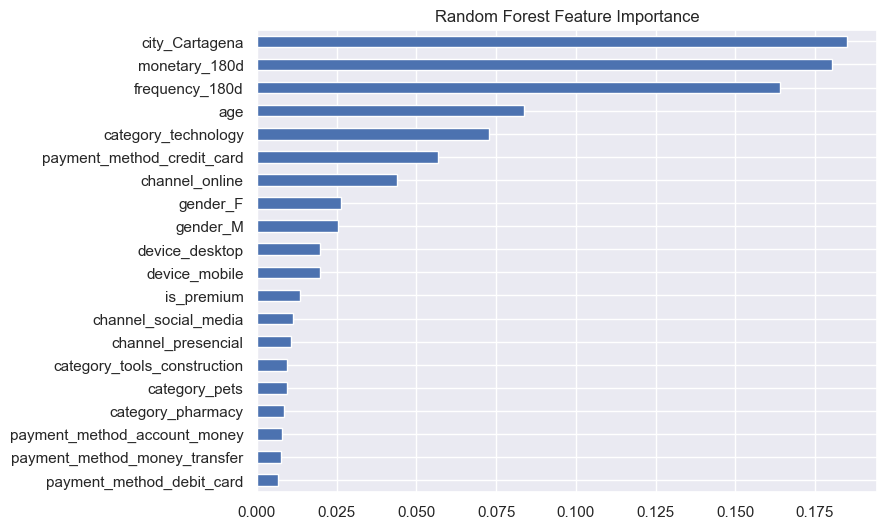

In [23]:
# ===============================
# IMPORTANCIA DE VARIABLES
# ===============================

def get_feature_names(preprocessor, categorical_cols, numerical_cols):
    """
    Retorna los nombres de las features después del ColumnTransformer
    """
    feature_names = []

    # Numéricas
    if 'num' in preprocessor.named_transformers_:
        num_features = preprocessor.named_transformers_['num'].get_feature_names_out(numerical_cols)
        feature_names.extend(num_features)

    # Categóricas
    if 'cat' in preprocessor.named_transformers_:
        cat_features = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_cols)
        feature_names.extend(cat_features)

    return feature_names


def mostrar_feature_importance(modelo, preprocessor, categorical_cols, numerical_cols):
    feature_names = get_feature_names(preprocessor, categorical_cols, numerical_cols)

    if hasattr(modelo, "feature_importances_"):  # Random Forest
        importances = modelo.feature_importances_
        feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
        print("\n🌲 Importancia de features (Random Forest):")
        print(feat_importances.head(15))
        feat_importances.head(20).plot(kind="barh", figsize=(8, 6), title="Random Forest Feature Importance")
        plt.gca().invert_yaxis()
        plt.show()

    elif hasattr(modelo, "coef_"):  # Regresión Logística
        coefs = modelo.coef_[0]
        coef_importance = pd.Series(coefs, index=feature_names).sort_values(key=abs, ascending=False)
        print("\n📊 Coeficientes (Regresión Logística):")
        print(coef_importance.head(15))
        coef_importance.head(20).plot(kind="barh", figsize=(8, 6), title="Logistic Regression Coefficients")
        plt.gca().invert_yaxis()
        plt.show()
    else:
        print("⚠️ El modelo no soporta importancia de features.")


# ===============================
# USO CON EL MEJOR MODELO
# ===============================
best_clf = mejor_modelo.named_steps["classifier"]
best_preprocessor = mejor_modelo.named_steps["preprocessor"]

mostrar_feature_importance(best_clf, best_preprocessor, categorical_cols, numerical_cols)


### Como se puede observar en la grafica el mejor modelo fue el RandomForest con un Average Precison de la Curva PR de 0.7612

# 4) Comunicación 
## Redacta 5–8 bullets con:
- Segmento objetivo (a quién impactar primero y por qué).
- Próxima campaña (canal, frecuencia, incentivo).
- Métricas de negocio a monitorear (lift, conversión incremental, ROI estimado).
- Riesgos o datos faltantes prioritarios.

## 1. En cuanto a la pobalación a impactar se podria decir deberian ser aquellos clientes que realizan compras en la categoria de tecnologia, usan medio de pago tarjeta de credito y su canal de compra es el online. Adicional a esto se puede decir que otra caracteriscas de los usuarios pueden ser que tengan tanto montos como frecuencias altas en lso ultimos 180d y por supuesto que a los usuarios que tengan al menos una compra en el ultimo mes. Esto tiene un por qué dado que son los perfiles que mejor segmentan la población basado en los diferentes arboles.  

## 2. La metrica de negocio que se podria seguir para esta campaña podrian estar asociadas a la medición del Churn, es decir, si yo le doy un incentivo a un cliente que tan probable es que en una ventana de 15d realice otra compra de forma organica sin tener ningun incentivo adicional. Asi mismo, tambien se puede medir el convertion incremental de estos usuarios, es decir, realizar un experimento con los usuarios tanto que tuvieron un incentivo para realizar una compra y quienes no, respecto a si hubo una compra efectiva. 

## 3. Los casos puntuales donde se puede presentar datos faltantes es para los clientes nuevos donde no se tiene algunas o todas las variables necesarias. En este caso se recomienda usar vectores de similutd con las variablea disponibles para construir dichos perfiles, por ejemplo, se puede realizar el analsis de que tan similes son 2 clientes basados en la información disponnible. En muchos casos donde implica tener la información del dispositivo del usuario (este es un dato que cuenta con muchos faltantes) se hace imperativo que se pueda validar con otro tipo de información complementaria: como la IP o el Canal desde donde se realiza la compra. Asi mismo, muchos de estos faltantes en los datos se pueden subsanar con reglas de negocio, esto por supuesto entre dice que se deber tener una buena, fluida y constante comunicación con el equipo de negocio para poder solventar estos errores de faltantes de datos. 